<h1 style="color:#001069ff; border-bottom:3px solid #242f6dff; padding-bottom:8px;">🎨 Image Segmentation with ClipSeg</h1>

Este notebook demonstra como realizar a segmentação de imagens usando o modelo **CIDAS/clipseg-rd64-refined** do Hugging Face. 

<h3 style="color:#242f6d;">O que é o ClipSeg?</h3>
O ClipSeg é um modelo de segmentação zero-shot que utiliza o backbone do CLIP. Ele permite segmentar objetos em uma imagem a partir de prompts de texto ou até mesmo de outras imagens de referência, sem precisar de treinamento específico para as classes que você deseja encontrar.

---

<br>
<h2 style="color:#001069;">🚀 Configuração e Carregamento do Modelo</h2>

Vamos carregar o processador e o modelo pré-treinado.

In [1]:
from transformers import CLIPSegProcessor, CLIPSegForImageSegmentation
from PIL import Image
import torch
import matplotlib.pyplot as plt
import os
import numpy as np

# Carregando o modelo e o processador
model_name = "CIDAS/clipseg-rd64-refined"
processor = CLIPSegProcessor.from_pretrained(model_name)
model = CLIPSegForImageSegmentation.from_pretrained(model_name)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

print(f"Modelo carragado no: {device}")

c:\Users\joao_\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\joao_\AppData\Local\Programs\Python\Python313\Lib\site-packages\huggingface_hub\file_download.py:140: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\joao_\.cache\huggingface\hub\models--CIDAS--clipseg-rd64-refined. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as 

Modelo carragado no: cpu


<br>
<h2 style="color:#001069;">🖼️ Processamento das Imagens</h2>

Vamos mapear as imagens da pasta `imagens` com alguns prompts de exemplo para ver a segmentação funcionando.

In [4]:
image_dir = "../imagens"
images_and_prompts = {
    "bird.jpg": ["bird", "branch"],
    "cats_dog.png": ["cat", "dog", "bed"],
    "kitchen.png": ["cabinet", "countertop", "sink", "stove", "refrigerator", "garlic", "spoon", "vase"],
    "pizza.png": ["pizza slice", "pepperoni", "cheese", "pizza", "table"]
}

def segment_image(image_path, prompts):
    # Carregar imagem
    image = Image.open(image_path).convert("RGB")
    
    # Processar inputs
    inputs = processor(text=prompts, images=[image] * len(prompts), padding="max_length", return_tensors="pt").to(device)
    
    # Predição
    with torch.no_grad():
        outputs = model(**inputs)
    
    # O output é um tensor de (len(prompts), 352, 352)
    preds = torch.sigmoid(outputs.logits)
    
    return image, preds

def plot_results(image, preds, prompts):
    n = len(prompts)
    fig, ax = plt.subplots(1, n + 1, figsize=((n + 1) * 4, 4))
    
    # Mostrar imagem original
    ax[0].imshow(image)
    ax[0].set_title("Original")
    ax[0].axis("off")
    
    # Mostrar máscaras para cada prompt
    for i, prompt in enumerate(prompts):
        mask = preds[i].cpu().numpy()
        ax[i+1].imshow(image)
        ax[i+1].imshow(mask, alpha=0.6, cmap='jet')
        ax[i+1].set_title(f"Prompt: {prompt}")
        ax[i+1].axis("off")
    
    plt.show()

<h3 style="color:#242f6d;">🔍 Visualizando Resultados</h3>

Agora vamos percorrer nossa lista de imagens e prompts predefinidos.

Processando: bird.jpg...


c:\Users\joao_\AppData\Local\Programs\Python\Python313\Lib\site-packages\transformers\image_processing_utils.py:41: UserWarning: The following named arguments are not valid for `ViTImageProcessor.preprocess` and were ignored: 'padding'
  return self.preprocess(images, **kwargs)


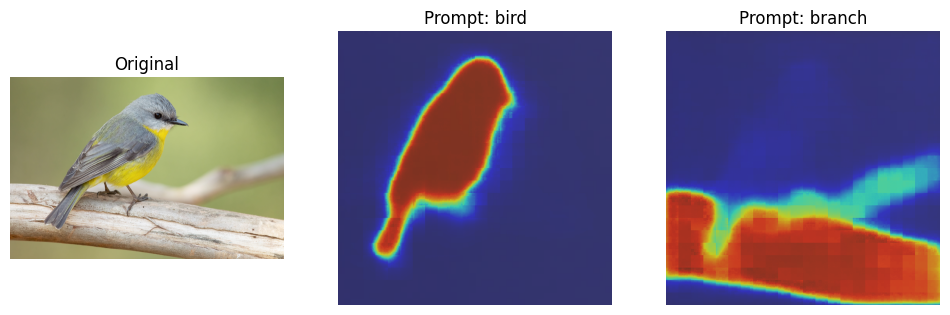

Processando: cats_dog.png...


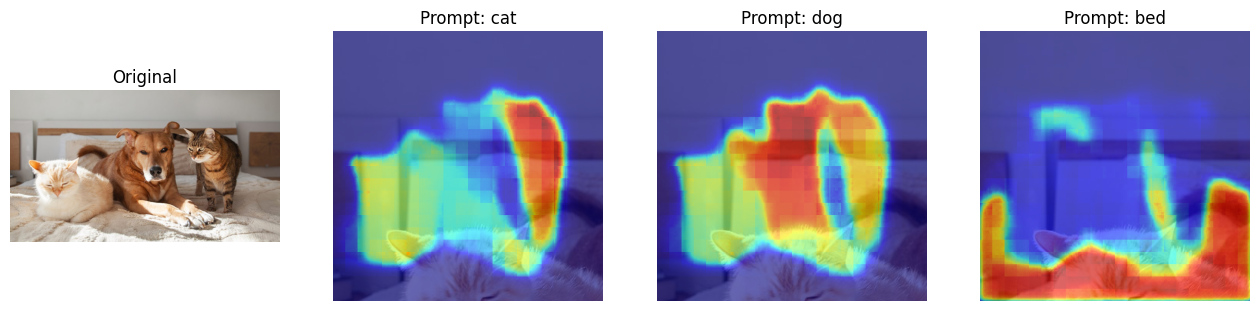

Processando: kitchen.png...


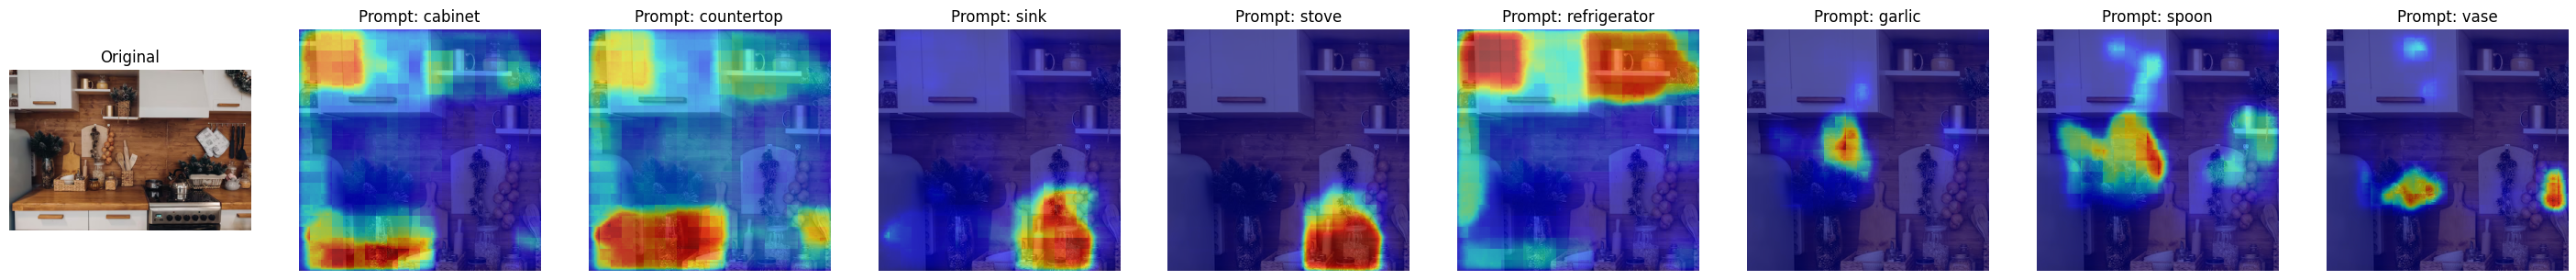

Processando: pizza.png...


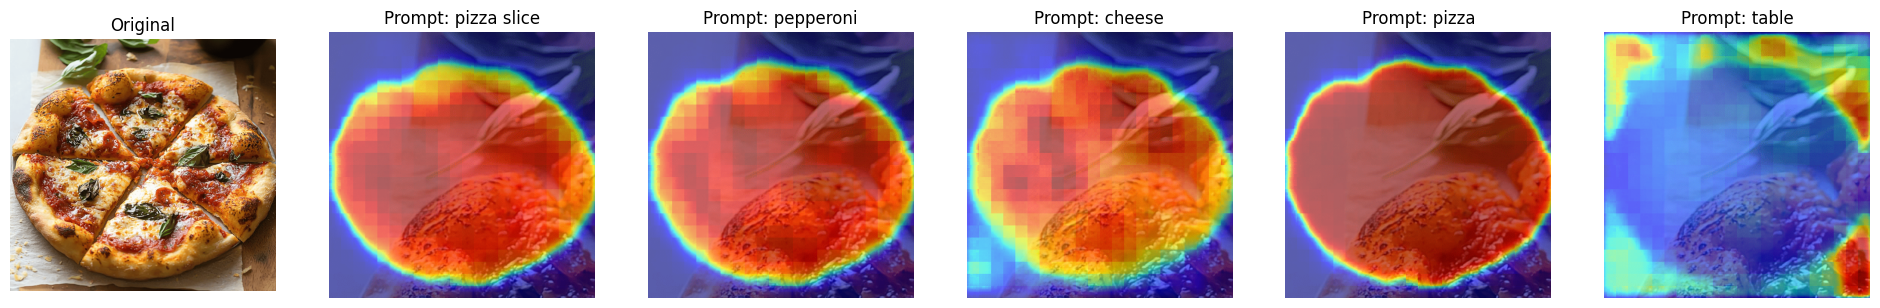

In [5]:
for img_name, prompts in images_and_prompts.items():
    path = os.path.join(image_dir, img_name)
    if os.path.exists(path):
        print(f"Processando: {img_name}...")
        img, prediction = segment_image(path, prompts)
        plot_results(img, prediction, prompts)
    else:
        print(f"Aviso: {img_name} não encontrada em {image_dir}.")

<br>
<h2 style="color:#001069;">💡 Como funciona?</h2>

O modelo ClipSeg usa o **CLIP** para alinhar as representações visuais e textuais. Ele recebe um prompt (ex: "pizza") e gera um mapa de ativação que destaca os pixels que mais se assemelham a esse conceito. 

- **Escalabilidade**: Diferente de modelos clássicos como Mask R-CNN que precisam de classes fixas, o ClipSeg pode segmentar qualquer coisa que o CLIP conheça.
- **Flexibilidade**: Você pode usá-lo para encontrar objetos específicos em cenas complexas apenas variando o texto.